Initial Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/train.csv')
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

Part 1: Data Cleaning 

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


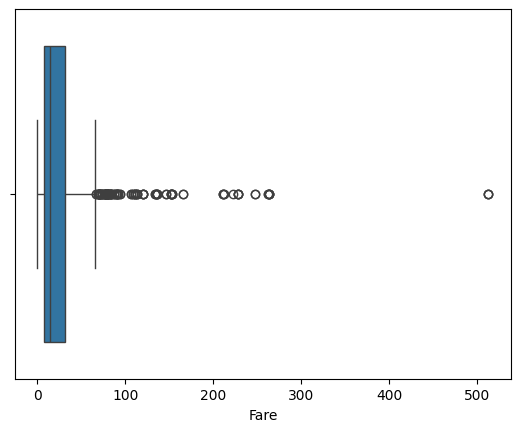

Sex
male      577
female    314
Name: count, dtype: int64
Cleaned data saved.


In [2]:
# Reload to reset (if rerunning)
df = pd.read_csv('../data/train.csv')

# Missing handling
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
if 'Cabin' in df.columns:
    df = df.drop('Cabin', axis=1)

print(df.isnull().sum())

# Outliers
sns.boxplot(x=df['Fare'])
plt.show()
fare_cap = df['Fare'].quantile(0.99)
df['Fare'] = df['Fare'].clip(upper=fare_cap)

# Consistency
print(df['Sex'].value_counts())
df = df.drop_duplicates()
columns_to_drop = ['PassengerId', 'Ticket']
df = df.drop([col for col in columns_to_drop if col in df.columns], axis=1)

# Save
df.to_csv('../data/train_cleaned.csv', index=False)
print("Cleaned data saved.")

Part 2: Feature Engineering

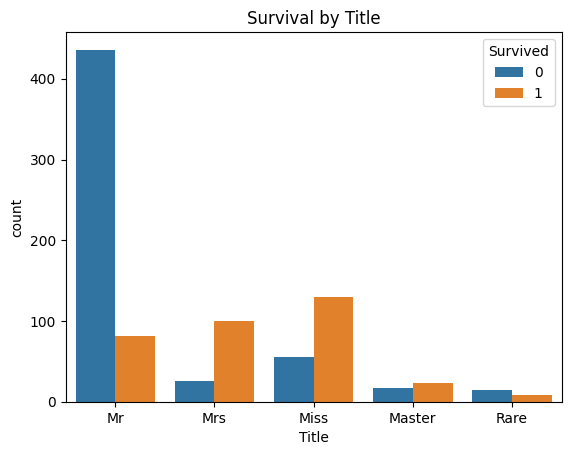

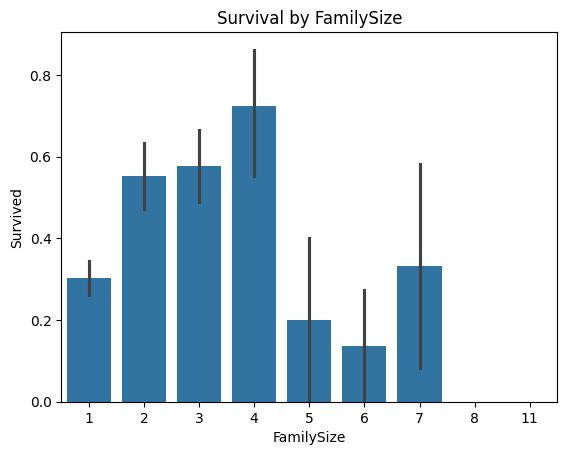

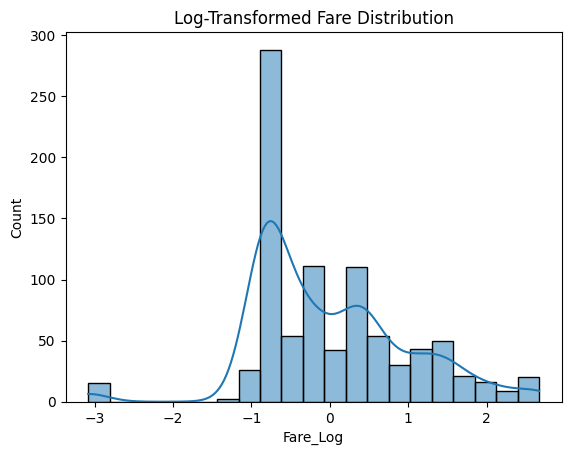

Engineered data saved.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('../data/train_cleaned.csv')

# Derived features
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Reload original for Name and Cabin
original_df = pd.read_csv('../data/train.csv')
df['Title'] = original_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Drop Name now that Title is extracted (fixes corr error in Part 3)
df = df.drop('Name', axis=1)

df['Deck'] = original_df['Cabin'].str[0]
df['Deck'] = df['Deck'].fillna('Unknown')

bins = [0, 12, 18, 60, 120]
labels = ['Child', 'Teen', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

df['FarePerPerson'] = df['Fare'] / df['FamilySize']

# Visualizations
sns.countplot(x='Title', hue='Survived', data=df)
plt.title('Survival by Title')
plt.show()

sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title('Survival by FamilySize')
plt.show()

# Categorical encoding
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title', 'Deck', 'AgeGroup'], drop_first=True)

# Interaction features (optional)
df['Pclass_Fare'] = df['Pclass'] * df['Fare']

# Transformations
df['Fare_Log'] = np.log1p(df['Fare'])
df['Age_Log'] = np.log1p(df['Age'])

scaler = StandardScaler()
numerical_cols = ['Age', 'Fare', 'FamilySize', 'FarePerPerson', 'Pclass_Fare', 'Fare_Log', 'Age_Log']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Visualize transformation
sns.histplot(df['Fare_Log'], kde=True)
plt.title('Log-Transformed Fare Distribution')
plt.show()

# Save engineered data
df.to_csv('../data/train_engineered.csv', index=False)
print("Engineered data saved.")

Part 3: Feature Selection

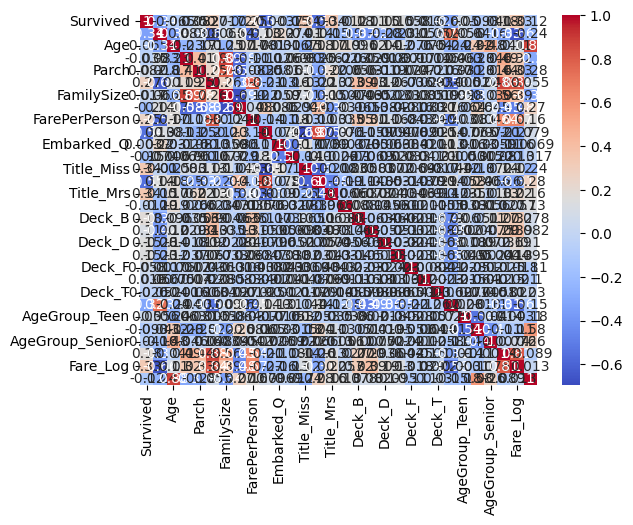

Dropped: ['FamilySize', 'FarePerPerson', 'Title_Mr', 'Pclass_Fare', 'Fare_Log', 'Age_Log']
Fare               0.215105
Age                0.206249
Sex_male           0.161393
Title_Mrs          0.071027
Pclass             0.064107
Title_Miss         0.048149
SibSp              0.043232
Deck_Unknown       0.033932
Parch              0.030615
Embarked_S         0.023556
IsAlone            0.018727
AgeGroup_Adult     0.017102
Deck_E             0.011504
Embarked_Q         0.010059
Deck_C             0.009083
Deck_B             0.008706
Deck_D             0.006887
Title_Rare         0.006147
AgeGroup_Teen      0.005717
Deck_F             0.003232
AgeGroup_Senior    0.003178
Deck_G             0.002028
Deck_T             0.000264
dtype: float64


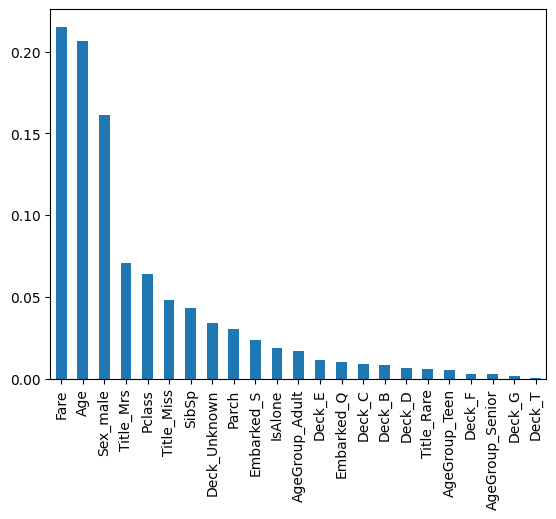

Selected: ['Fare', 'Age', 'Sex_male', 'Title_Mrs', 'Pclass', 'Title_Miss', 'SibSp', 'Deck_Unknown', 'Parch', 'Embarked_S', 'IsAlone', 'AgeGroup_Adult', 'Deck_E', 'Embarked_Q']
RFE: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_S', 'Title_Miss', 'Title_Mrs', 'Deck_Unknown']
Selected data saved.


In [7]:
# Load engineered
df = pd.read_csv('../data/train_engineered.csv')

# Correlation
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

high_corr_threshold = 0.8
corr_matrix = corr.abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > high_corr_threshold)]
df = df.drop(to_drop, axis=1)
print(f"Dropped: {to_drop}")

# Importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
importances.plot(kind='bar')
plt.show()

importance_threshold = 0.01
selected_features = importances[importances > importance_threshold].index.tolist()
df = df[selected_features + ['Survived']]
print(f"Selected: {selected_features}")

# Optional RFE
from sklearn.feature_selection import RFE
rfe = RFE(model, n_features_to_select=10)
rfe.fit(X_train, y_train)
rfe_features = X.columns[rfe.support_].tolist()
print(f"RFE: {rfe_features}")

# Save
df.to_csv('../data/train_selected.csv', index=False)
print("Selected data saved.")